# GARCH Forecast on IRS

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from arch import arch_model          # pip install arch if missing

plt.style.use("ggplot")              
DATA = Path("../data/raw_yfinance")  


In [2]:
prices = (
    pd.read_parquet(DATA / "prices_arg.parquet")["IRS"]
    .asfreq("B")
    .ffill(limit=1)                      # same gap logic as build script
)

# Log-returns in %
rets = 100 * np.log(prices).diff().dropna()
rets.name = "IRS_ret"


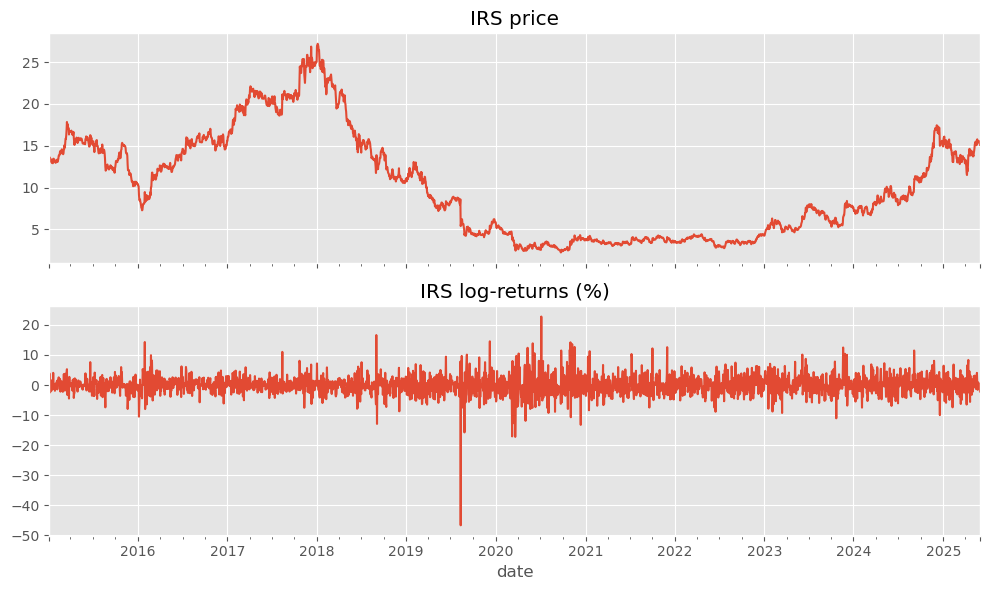

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
prices.plot(ax=ax[0], title="IRS price")
rets.plot(ax=ax[1], title="IRS log-returns (%)")
plt.tight_layout(); plt.show()


In [4]:
garch11 = arch_model(
    rets,
    p=1, q=1,
    mean="Constant",     # can switch to 'Zero' if constant not sig.
    vol="GARCH",
    dist="t"             # Student-t → fatter tails
)

res = garch11.fit(update_freq=0, show_warning=False)
print(res.summary())


Optimization terminated successfully    (Exit mode 0)
            Current function value: 6675.8693327399
            Iterations: 19
            Function evaluations: 133
            Gradient evaluations: 19
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      IRS_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6675.87
Distribution:      Standardized Student's t   AIC:                           13361.7
Method:                  Maximum Likelihood   BIC:                           13391.3
                                              No. Observations:                 2715
Date:                      Mon, Jul 07 2025   Df Residuals:                     2714
Time:                              16:25:52   Df Model:                            1
                           

In [5]:
# h=1 → next-day variance forecast. reindex=False to keep same index.
var_fcast = res.forecast(reindex=False, horizon=1).variance["h.1"]
sigma = np.sqrt(var_fcast)             # std-dev (%)
sigma.name = "σ_forecast"

fcast = res.forecast(start=0, horizon=1, reindex=True)
sigma_fwd1 = np.sqrt(fcast.variance["h.1"])
sigma_fwd1.name = "σ_forecast"
print(type(fcast))                     # ARCHModelForecast
print(fcast.variance.head())           # should be a DataFrame



<class 'arch.univariate.base.ARCHModelForecast'>
                 h.1
date                
2015-01-05  3.162661
2015-01-06  4.265516
2015-01-07  4.174550
2015-01-08  4.489614
2015-01-09  4.378921


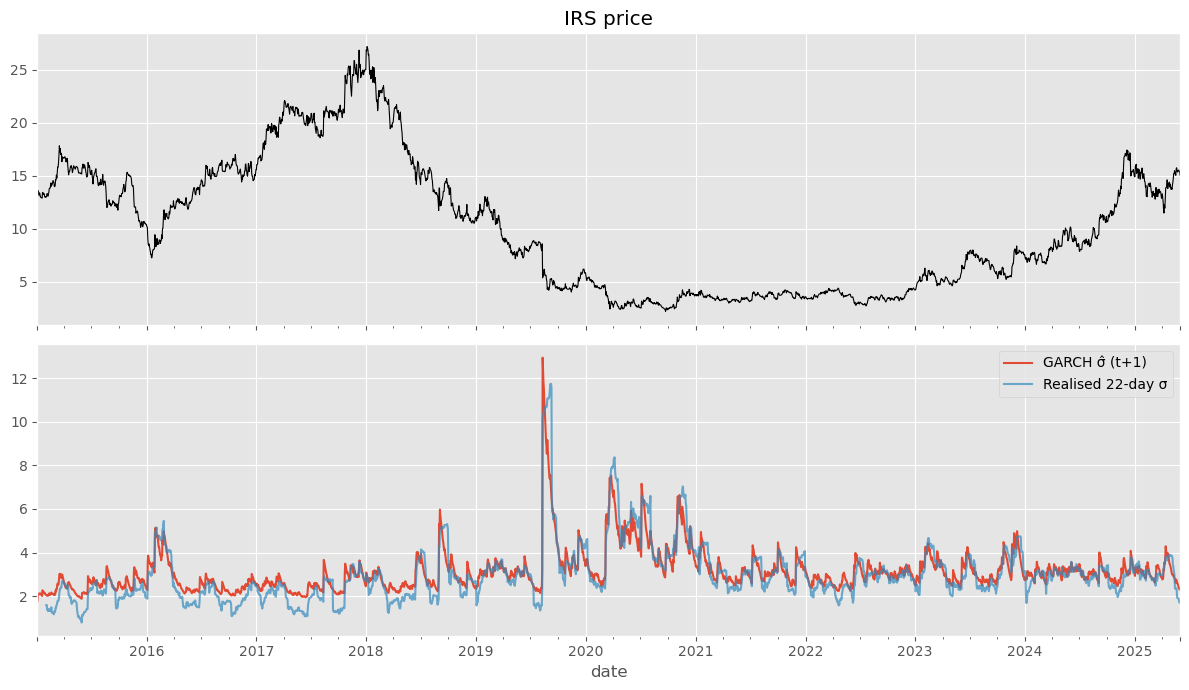

In [6]:
realised = rets.rolling(22).std()      # 1-month realised vol (%)
realised.name = "σ_realised"

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
prices.plot(ax=ax[0], color="black", lw=0.8, title="IRS price")
sigma_fwd1.plot(ax=ax[1], label="GARCH σ̂ (t+1)")
realised.plot(ax=ax[1], label="Realised 22-day σ", alpha=0.7)
ax[1].legend()
plt.tight_layout()
plt.savefig("../docs/model_results/garch_irs_sigma.png", dpi=300)
plt.show()
